# DecisionTreeRegressor

결정트리 회귀(Decision Tree Regressor)는 연속형 숫자를 예측하는 트리 기반 회귀 모델이다.

분류용 결정트리가 **어느 클래스인지** 를 맞히는 모델이었다면, 회귀용 결정트리는 **얼마나 큰 값인지**를 예측하는 모델이다.

쉽게 말하면,
데이터를 조건문으로 계속 나눈 뒤 마지막 구역(리프 노드, leaf node)에 도착하면 그 구역에 들어 있던 타깃값들의 대표값(보통 평균)을 예측값으로 사용한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 보스턴 주택 가격 데이터 불러오기

In [2]:
housing_df = pd.read_csv('data/boston_housing_train.csv')
housing_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
# 데이터 구조 확인
print(housing_df.shape)
print(housing_df.columns.tolist())

# 결측치 확인
print('\n결측치 개수')
print(housing_df.isnull().sum())

(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

결측치 개수
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
# 입력값(X)과 정답(y) 분리
X = housing_df.drop('MEDV', axis=1)
y = housing_df['MEDV']

print(X.shape, y.shape)
X.head()

(506, 13) (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [5]:
from sklearn.model_selection import train_test_split

# 학습용 / 평가용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

X_train: (404, 13) y_train: (404,)
X_test : (102, 13) y_test : (102,)


In [6]:
# 모델 학습
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,                    # 과적합 완화 (트리 최대 깊이 제한)
    criterion='squared_error'       # 분할 기준: 평균 제곱 오차 감소 방향
)

dt_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [7]:
from sklearn.metrics import mean_squared_error
# 모델 평가
trained_pred = dt_reg.predict(X_train)
tested_pred = dt_reg.predict(X_test)

train_r2 = dt_reg.score(X_train, y_train)
test_r2 = dt_reg.score(X_test, y_test)

train_mse = mean_squared_error(y_train, trained_pred)
test_mse = mean_squared_error(y_test, tested_pred)

print(f"학습셋 : {train_r2}, {train_mse}")
print(f"평가셋 : {test_r2}, {test_mse}")

학습셋 : 0.9185171013474737, 7.078696760120875
평가셋 : 0.8833565347917995, 8.553906584646844


## 트리 구조 시각화

- 회귀 트리에서는 분류 트리처럼 클래스 비율이 아니라 평균값과 오차 감소를 중심으로 본다.

속성
- squared_error: 해당 노드의 오차 정도
- samples: 그 노드에 들어온 데이터 개수
- value: 그 노드의 평균 예측값
- feature / threshold: 어떤 조건으로 나누는지

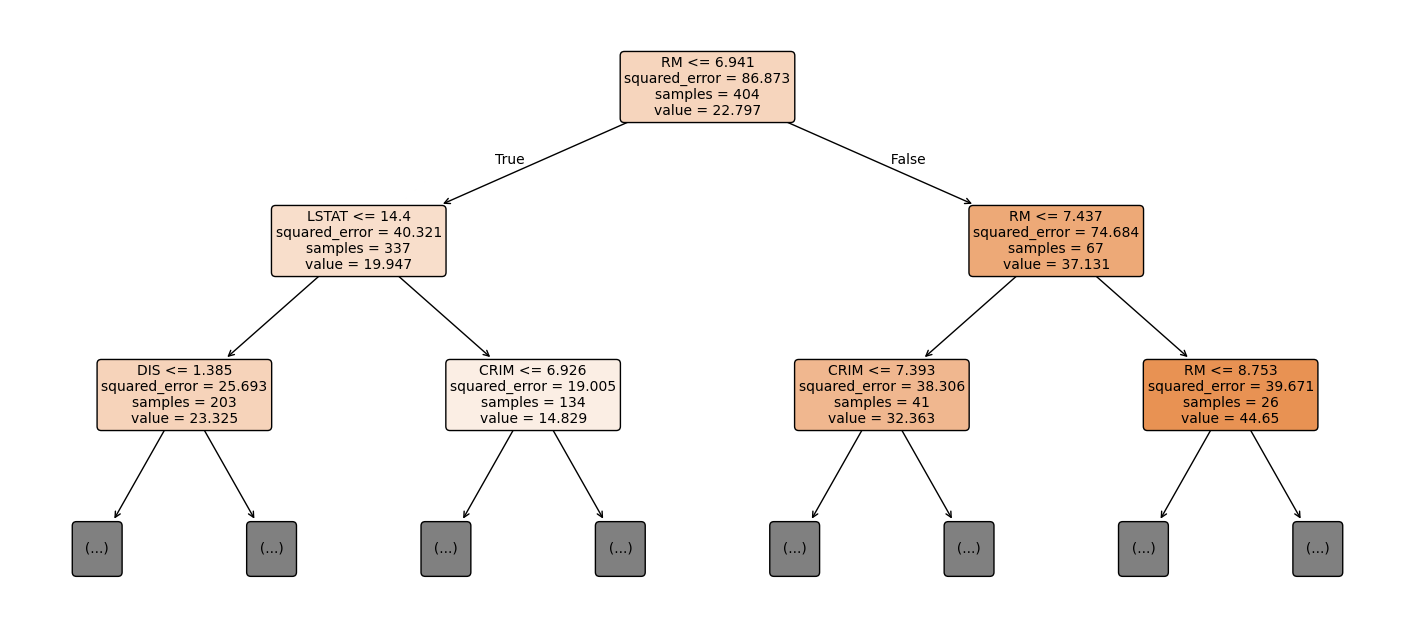

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(dt_reg, filled=True, feature_names=X.columns, max_depth=2, rounded=True, fontsize=10)
plt.show()

## 깊이에 따른 성능 비교

`max_depth`를 바꾸어 보면
- 깊이가 너무 얕으면 단순해서 충분히 학습하지 못하고
- 깊이가 너무 깊으면 학습 데이터를 외우듯 맞춰 과적합이 생길 수 있다.

In [9]:
depth_result = []

for depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]:
    model = DecisionTreeRegressor(random_state=42, max_depth=depth)
    model.fit(X_train, y_train)

    depth_result.append({
        'max_depth' : 'None' if depth is None else depth,
        'train_r2': model.score(X_train, y_train),
        'test_r2': model.score(X_test, y_test)
    })

depth_df = pd.DataFrame(depth_result)
depth_df    

,max_depth,train_r2,test_r2
0,1,0.470264,0.360216
1,2,0.704689,0.645550
2,3,0.816956,0.771366
3,4,0.888202,0.730687
4,5,0.918517,0.883357
5,6,0.941689,0.878244
6,7,0.962518,0.877223
7,8,0.977565,0.877567
8,9,0.986973,0.878756
9,10,0.993649,0.692842


## 특성 중요도(feature importance)

결정트리는 어떤 특성을 상대적으로 더 많이 참고했는지
`feature_importances_` 속성으로 보여줄 수 있다.

주의
- 중요도가 높다고 해서 인과관계가 있다는 뜻은 아니다.
- 단지 이 트리가 분할을 만들 때 많이 활용했다는 의미로 이해하면 된다.

In [10]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_reg.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
5,RM,0.651196
12,LSTAT,0.194264
0,CRIM,0.068622
7,DIS,0.067445
6,AGE,0.006176
10,PTRATIO,0.004391
2,INDUS,0.003801
4,NOX,0.003561
11,B,0.000543
3,CHAS,0.000000


## 예측값 시각화

결정트리 회귀는 데이터를 구간으로 나눈 뒤 각 리프 노드에서 하나의 대표값(평균값)을 예측한다.
그래서 선형회귀처럼 매끈한 직선이 아니라 구간별로 값이 뚝뚝 바뀌는 계단형(piecewise constant) 예측을 만드는 경우가 많다.

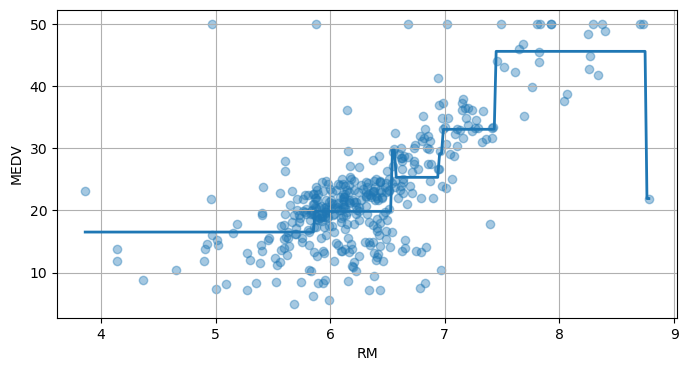

In [11]:
# 가장 중요한 특성 1개를 기준으로 실제 값과 예측 경향을 간단히 확인
top_feature = importance_df.iloc[0]['feature']

simple_tree = DecisionTreeRegressor(random_state=42, max_depth=3)
simple_tree.fit(X_train[[top_feature]], y_train)

x_line = np.linspace(X_train[top_feature].min(), X_train[top_feature].max(), 300)
y_line = simple_tree.predict(pd.DataFrame({top_feature : x_line}))

plt.figure(figsize=(8, 4))
plt.scatter(X_train[top_feature], y_train, alpha=0.4)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel(top_feature)
plt.ylabel('MEDV')
plt.grid()
plt.show()

## 정리

1. 결정트리 회귀는 조건문을 반복하며 데이터를 나눈다.
2. 마지막 리프 노드의 평균값으로 예측한다.
3. 스케일링보다 트리 깊이 같은 가지치기 설정이 더 중요하다.
4. 깊이가 너무 크면 과적합되기 쉽다.
5. 특성 중요도로 어떤 변수를 많이 참고했는지 볼 수 있다.
6. 예측값은 구간별 평균이라 계단형으로 나타날 수 있다.

이후 알고리즘과의 연결
- 랜덤포레스트: 여러 개의 트리를 모아 더 안정적으로 예측
- 그래디언트 부스팅: 틀린 부분을 보완하면서 트리를 순차적으로 학습